# Exercise 3 — Preparing real-world data for a `tanh` network

**Insper · Artificial Neural Networks and Deep Learning · Activity 1**
Author: Eduardo Takei Yaginuma

The dataset is the Kaggle [Spaceship Titanic](https://www.kaggle.com/competitions/spaceship-titanic)
`train.csv` (the only labelled file). The target network uses **`tanh`** in its hidden
layers, whose output lives in $(-1, 1)$ and whose gradient is largest around 0 and vanishes
beyond roughly $|z| > 2$ — that single fact drives every decision below.

The pipeline is deliberately explicit (no `ColumnTransformer` black box) so that every
statistic can be shown to come from the training split only.

> **Reproducibility.** Fixed seed `42` for the stratified split. Libraries: `numpy`,
> `pandas`, `matplotlib`, `scikit-learn` (**preprocessing only** — no model is trained).
> Same code as [`src/ex3_realworld.py`](../src/ex3_realworld.py).
>
> **Data.** `data/train.csv` is not committed to the repository (Kaggle terms). Download it
> from the competition page and drop it in `data/` before running this notebook.

In [1]:
"""Report style, inlined so the notebook runs standalone (mirrors src/style.py)."""
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib import font_manager as fm

%matplotlib inline

# ---- brand palette -----------------------------------------------------------
INK      = "#0A1729"   # primary text
INK_SOFT = "#11294A"   # secondary text
HAIRLINE = "#97A3B4"   # grid lines, spines
SURFACE  = "#F4F1E8"   # figure background
ACCENT   = "#8A6B33"   # thin accent strokes (sketched boundaries, reference lines)

# Categorical palette (fixed order) + redundant marker shapes, so class identity
# never depends on colour alone.
SERIES  = ["#2a78d6", "#eb6834", "#1baf7a", "#4a3aa7"]
MARKERS = ["o", "s", "^", "D"]

# ---- fonts: use the repo's if reachable, otherwise matplotlib defaults --------
_fontdir = next((p for p in (Path("assets/fonts"), Path("../assets/fonts")) if p.is_dir()), None)
if _fontdir:
    for _ttf in sorted(_fontdir.glob("*.ttf")):
        fm.fontManager.addfont(str(_ttf))
_have = {f.name for f in fm.fontManager.ttflist}
SERIF = "Spectral" if "Spectral" in _have else "DejaVu Serif"
SANS  = "Archivo" if "Archivo" in _have else "DejaVu Sans"
MONO  = "IBM Plex Mono" if "IBM Plex Mono" in _have else "DejaVu Sans Mono"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "figure.dpi": 110, "savefig.bbox": "tight",
    "font.family": SANS, "font.size": 9, "axes.titlesize": 11, "axes.labelsize": 9.5,
    "legend.fontsize": 8.5, "xtick.labelsize": 8, "ytick.labelsize": 8,
    "text.color": INK, "axes.labelcolor": INK_SOFT, "axes.titlecolor": INK,
    "xtick.color": INK_SOFT, "ytick.color": INK_SOFT,
    "axes.edgecolor": HAIRLINE, "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": HAIRLINE, "grid.linewidth": 0.5,
    "grid.alpha": 0.45, "axes.axisbelow": True,
    "legend.frameon": True, "legend.facecolor": SURFACE, "legend.edgecolor": HAIRLINE,
    "lines.linewidth": 2.0, "lines.markersize": 5,
})


def title(ax, text, sub=None):
    """Editorial title, placed with ax.text so title and deck never collide."""
    ax.text(0.0, 1.085 if sub else 1.02, text, transform=ax.transAxes,
            fontfamily=SERIF, fontsize=12, color=INK, va="bottom", ha="left")
    if sub:
        ax.text(0.0, 1.018, sub, transform=ax.transAxes, fontsize=8,
                color=INK_SOFT, va="bottom", ha="left")


def legend_row(ax, ncols=4, y=-0.16):
    """Legend as a single row under the plot, so it never covers the data."""
    return ax.legend(loc="upper center", bbox_to_anchor=(0.5, y), ncols=ncols,
                     frameon=False, handletextpad=0.4, columnspacing=1.4)


def halo(txt, lw=2.2):
    """Surface-coloured outline behind a label sitting on top of the data."""
    txt.set_path_effects([pe.withStroke(linewidth=lw, foreground=SURFACE)])
    return txt


def mono_ticks(ax):
    """Tick labels are numbers, so they wear the mono face."""
    for lbl in list(ax.get_xticklabels()) + list(ax.get_yticklabels()):
        lbl.set_fontfamily(MONO)


print(f"fonts: {SERIF} / {SANS} / {MONO}")

fonts: Spectral / Archivo / IBM Plex Mono


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler

# repo root is the parent of notebooks/, but the notebook also runs from the root
CSV = next(p for p in (Path("data/train.csv"), Path("../data/train.csv")) if p.exists())

TARGET = "Transported"
SPEND = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
NUMERIC = ["Age"] + SPEND
CATEGORICAL = ["HomePlanet", "CryoSleep", "Destination", "VIP"]
DROP = ["Cabin", "Name", "PassengerId"]     # identifiers / high-cardinality text
SEED = 42

df = pd.read_csv(CSV)
print(f"{CSV}: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

../data/train.csv: 8693 rows x 14 columns


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


---
## A — Get to know the data

**Goal of the dataset.** Each row is a passenger of the Spaceship Titanic, which collided
with a spacetime anomaly. `Transported` is the binary target: `True` means the passenger was
**transported to another dimension** by the anomaly, `False` means they were not. The task is
therefore binary classification from passenger records (origin, cabin, cryosleep status, age,
VIP status and on-board spending).

In [3]:
balance = df[TARGET].value_counts(normalize=True).sort_index()
print(f"Transported = True : {balance.get(True, 0):.2%}  ({int(df[TARGET].sum())} passengers)")
print(f"Transported = False: {balance.get(False, 0):.2%}  ({int((~df[TARGET]).sum())} passengers)")

Transported = True : 50.36%  (4378 passengers)
Transported = False: 49.64%  (4315 passengers)


**Class balance.** `True` = **50.36%** (4378 passengers), `False` = **49.64%** (4315). The
target is essentially balanced, so accuracy is a meaningful metric and no class weighting or
resampling is needed.

**Features by type.**

| Type | Columns |
|---|---|
| Numerical (6) | `Age`, `RoomService`, `FoodCourt`, `ShoppingMall`, `Spa`, `VRDeck` |
| Categorical (4) | `HomePlanet` (Earth/Europa/Mars), `CryoSleep` (bool), `Destination` (3 levels), `VIP` (bool) |
| Identifier / text (3) | `PassengerId`, `Cabin` (`deck/num/side`, ~6560 distinct values), `Name` |
| Target | `Transported` (bool) |

In [4]:
print(f"numerical   ({len(NUMERIC)}): {NUMERIC}")
print(f"categorical ({len(CATEGORICAL)}): {CATEGORICAL}")
for c in CATEGORICAL:
    print(f"  {c:<12} levels: {sorted(df[c].dropna().unique().tolist(), key=str)}")
print(f"dropped     ({len(DROP)}): {DROP}  (Cabin has {df['Cabin'].nunique()} distinct values)")

numerical   (6): ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
categorical (4): ['HomePlanet', 'CryoSleep', 'Destination', 'VIP']
  HomePlanet   levels: ['Earth', 'Europa', 'Mars']
  CryoSleep    levels: [False, True]
  Destination  levels: ['55 Cancri e', 'PSO J318.5-22', 'TRAPPIST-1e']
  VIP          levels: [False, True]
dropped     (3): ['Cabin', 'Name', 'PassengerId']  (Cabin has 6560 distinct values)


In [5]:
# ---- missing values, absolute and percentage --------------------------------
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
}).sort_values("missing_count", ascending=False)

print(f"total missing cells: {int(df.isna().sum().sum())}")
missing

total missing cells: 2324


,missing_count,missing_pct
CryoSleep,217,2.50
ShoppingMall,208,2.39
VIP,203,2.34
HomePlanet,201,2.31
Name,200,2.30
Cabin,199,2.29
VRDeck,188,2.16
FoodCourt,183,2.11
Spa,183,2.11
Destination,182,2.09


In [6]:
# ---- spending columns: mean, median, maximum --------------------------------
spend_stats = df[SPEND].agg(["mean", "median", "max"]).T
# The median is 0 for every spending column, so the ratio is undefined; keep it
# as None rather than inf, which is not valid JSON and breaks strict parsers.
spend_stats["mean_over_median"] = [
    round(mean / median, 4) if median > 0 else None
    for mean, median in zip(spend_stats["mean"], spend_stats["median"])
]
spend_stats.round(2)

,mean,median,max,mean_over_median
RoomService,224.69,0.0,14327.0,None
FoodCourt,458.08,0.0,29813.0,None
ShoppingMall,173.73,0.0,23492.0,None
Spa,311.14,0.0,22408.0,None
VRDeck,304.85,0.0,24133.0,None


**Missing values.** 2324 missing cells in total, spread thinly across almost every column —
no column above 2.5%, and the target has none.

**Mean versus median.** For all five spending columns the **median is 0** while the mean sits
between 174 and 458 — and the maximum reaches **29 813** (`FoodCourt`). A median of zero says
that *more than half of the passengers spend nothing at all* in each venue; a mean two to three
orders of magnitude below the maximum says the average is being dragged upward by a small
minority of very large spenders. In other words these distributions are **extremely
right-skewed, zero-inflated and heavy-tailed**: not spread symmetrically around a centre, but
a spike at zero plus a long thin tail. That is precisely the shape that breaks a `tanh`
network if fed raw, and the reason for the $\log(1+x)$ step in item C.

---
## B — Split before you transform

> **Data leakage.** Every statistic used in the transformation — mean, standard deviation,
> median, observed categories — must be computed **only** on the training set. Computing it
> on the full dataset and splitting afterwards is data leakage, and the reported performance
> stops being trustworthy.

In [7]:
def split(df):
    """80/20 stratified split with a fixed seed - before any statistic is computed."""
    X = df.drop(columns=[TARGET])
    y = df[TARGET].astype(int)
    return train_test_split(X, y, test_size=0.20, random_state=SEED, stratify=y)


X_train, X_test, y_train, y_test = split(df)
print(f"train: {X_train.shape[0]} rows, positive share {y_train.mean():.2%}")
print(f"test : {X_test.shape[0]} rows, positive share {y_test.mean():.2%}")

# FoodCourt on the training split, before any transformation (report summary #11)
fc_mean, fc_median = X_train["FoodCourt"].mean(), X_train["FoodCourt"].median()
print(f"FoodCourt on train before transforming: mean = {fc_mean:.2f}, median = {fc_median:.2f}")

train: 6954 rows, positive share 50.36%
test : 1739 rows, positive share 50.37%
FoodCourt on train before transforming: mean = 452.61, median = 0.00


Result: **6954** training rows and **1739** test rows, with the positive class at **50.36%**
in train and **50.37%** in test — stratification preserved the balance.

**Why the split comes first.** Every transformation below is *fitted*: the imputation median,
the modal category, the set of observed categories, the Min-Max range. Those are statistics
learned from data, i.e. model parameters. If they are computed over the full dataset, each
training example is preprocessed using information taken from the test rows, and the test set
stops being unseen data — the reported performance is then optimistic and does not transfer to
production. Splitting first and fitting only on the training split makes the test set behave
like data that arrives after the model is deployed, which is the only thing that makes its
score trustworthy.

---
## C — Preprocess

The `tanh` activation outputs values in $[-1, 1]$, so the inputs must be on a compatible
scale. Seven steps, each one fitted on the training split and applied to both.

### 1. Drop the identifier columns

`Cabin`, `Name` and `PassengerId` go: two are identifiers with no generalising content, and
`Cabin` is a high-cardinality composite string (`deck/num/side`) that would need its own
parsing.

In [8]:
Xtr = X_train.drop(columns=DROP).copy()
Xte = X_test.drop(columns=DROP).copy()
print(f"columns kept ({Xtr.shape[1]}): {list(Xtr.columns)}")

columns kept (10): ['HomePlanet', 'CryoSleep', 'Destination', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']


### 2–3. Missing data — one strategy per column type

| Type | Strategy | Justification |
|---|---|---|
| Numerical (`Age` + 5 spending) | **Median** of the training split | The spending columns are heavily right-skewed, so the mean is pulled by outliers while the median is robust. For spending the training median is `0.0`, which coincides with the natural reading of a missing value here ("no purchase recorded") — median imputation and zero-filling agree, and the median needs no extra assumption. For `Age` (2.06% missing) the median (27) is a safe central value that does not invent an extreme. |
| Categorical (`HomePlanet`, `CryoSleep`, `Destination`, `VIP`) | **Most frequent** category of the training split | Missingness is low (2.1–2.5%), so the mode barely shifts the distribution. `CryoSleep` and `VIP` are booleans: adding a third `"Missing"` level would create a category that carries almost no data and one extra one-hot column each. (With higher missing rates an explicit `"Missing"` level would be the better choice, since "not recorded" can itself be informative.) |

Both imputers are `fit` on `X_train` and only `transform`ed on `X_test`, so the median and the
mode come exclusively from training data.

In [9]:
# -- 2. numeric imputation (median learned on train only)
num_imp = SimpleImputer(strategy="median").fit(Xtr[NUMERIC])
Xtr[NUMERIC] = num_imp.transform(Xtr[NUMERIC])
Xte[NUMERIC] = num_imp.transform(Xte[NUMERIC])

# -- 3. categorical imputation (mode learned on train only); booleans as strings
for d in (Xtr, Xte):
    d[CATEGORICAL] = d[CATEGORICAL].astype("object")
cat_imp = SimpleImputer(strategy="most_frequent").fit(Xtr[CATEGORICAL])
Xtr[CATEGORICAL] = cat_imp.transform(Xtr[CATEGORICAL])
Xte[CATEGORICAL] = cat_imp.transform(Xte[CATEGORICAL])

print("statistics learned on the TRAINING split only:")
for c, v in zip(NUMERIC, num_imp.statistics_):
    print(f"  median {c:<13} = {v}")
for c, v in zip(CATEGORICAL, cat_imp.statistics_):
    print(f"  mode   {c:<13} = {v}")
print(f"\nremaining NaN - train {int(Xtr.isna().sum().sum())}, test {int(Xte.isna().sum().sum())}")

statistics learned on the TRAINING split only:
  median Age           = 27.0
  median RoomService   = 0.0
  median FoodCourt     = 0.0
  median ShoppingMall  = 0.0
  median Spa           = 0.0
  median VRDeck        = 0.0
  mode   HomePlanet    = Earth
  mode   CryoSleep     = False
  mode   Destination   = TRAPPIST-1e
  mode   VIP           = False

remaining NaN - train 0, test 0


### 4. Feature engineering — `TotalSpend`

The sum of the five spending columns, computed **after imputation and before** the log
transform, so it is a true total in credits. It gives the network a single "did this passenger
spend anything at all, and how much" signal instead of forcing it to learn a sum of five inputs.

In [10]:
Xtr["TotalSpend"] = Xtr[SPEND].sum(axis=1)
Xte["TotalSpend"] = Xte[SPEND].sum(axis=1)

raw_foodcourt_train = Xtr["FoodCourt"].copy()   # kept for Figure 6
Xtr[["TotalSpend"] + SPEND].describe().round(2)

,TotalSpend,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,6954.00,6954.00,6954.00,6954.00,6954.00,6954.00
mean,1426.55,225.35,442.59,165.90,302.21,290.51
std,2755.56,670.06,1586.02,542.68,1130.62,1097.86
min,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.00,0.00,0.00,0.00,0.00
50%,715.00,0.00,0.00,0.00,0.00,0.00
75%,1442.00,43.00,54.75,20.00,48.00,36.75
max,35987.00,14327.00,29813.00,12253.00,22408.00,20336.00


### 5. Heavy tails — $\log(1 + x)$

$\log(1+x)$ is used rather than $\log x$ because it maps $0 \mapsto 0$, and the majority of
the values *are* zero. Note that it is a **fixed function**, not a fitted statistic, so
applying it to both splits leaks nothing.

**Why this helps a `tanh` network.** A hidden unit computes $\tanh(w^\top x + b)$. With a raw
feature reaching $3 \times 10^4$, any weight that is not microscopic pushes the pre-activation
deep into the saturated region where $\tanh' \approx 0$: the unit outputs $\pm 1$ for nearly
every passenger and its gradient vanishes, so the layer stops learning (and gradient descent
has to cope with wildly different scales per feature at the same time). Even after rescaling to
$[-1, 1]$, a *raw* heavy-tailed column would be useless for a different reason: **83%** of the
training passengers would sit inside a band just $0.03$ wide next to $-1$, and 99% of them
below $-0.47$ — a compact blob the network cannot resolve — while the top 1% of spenders
stretch across the remaining half of the axis. The log compresses the tail *before* the
rescaling, spreading the bulk of the passengers across the whole interval and turning ratios
into differences, which is the scale on which spending actually differs.

In [11]:
heavy = SPEND + ["TotalSpend"]
Xtr[heavy] = np.log1p(Xtr[heavy])
Xte[heavy] = np.log1p(Xte[heavy])

print(f"FoodCourt range: [{raw_foodcourt_train.min():.0f}, {raw_foodcourt_train.max():.0f}]"
      f"  ->  after log1p [{Xtr['FoodCourt'].min():.1f}, {Xtr['FoodCourt'].max():.1f}]")

# the argument above, measured: where the passengers would sit WITHOUT the log
_raw_mm = -1 + 2 * (raw_foodcourt_train - raw_foodcourt_train.min()) / \
    (raw_foodcourt_train.max() - raw_foodcourt_train.min())
print(f"without log1p, Min-Max to [-1, 1]: 83rd pct = {_raw_mm.quantile(0.83):.4f}, "
      f"99th pct = {_raw_mm.quantile(0.99):.4f}")

FoodCourt range: [0, 29813]  ->  after log1p [0.0, 10.3]
without log1p, Min-Max to [-1, 1]: 83rd pct = -0.9720, 99th pct = -0.4673


### 6. Categorical features → numbers

One-hot encoding with `OneHotEncoder(handle_unknown="ignore", sparse_output=False)`, fitted on
the training split.

**A category that appears in the test set but not in training** is handled by
`handle_unknown="ignore"`: the encoder was fitted on the training categories only, so the
transformed test row gets **0 in every column of that feature's block** instead of raising an
error or silently adding a column. This matters for two reasons: the feature matrix keeps
exactly the same width and column order in train and test (a network's input layer has a fixed
size), and an unknown value degrades gracefully to "no evidence from this feature" rather than
being mapped onto some arbitrary known category. The alternative, `handle_unknown="error"`,
would crash at inference time on the first unseen value.

In [12]:
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False).fit(Xtr[CATEGORICAL])
ohe_cols = list(ohe.get_feature_names_out(CATEGORICAL))
Otr = pd.DataFrame(ohe.transform(Xtr[CATEGORICAL]), columns=ohe_cols, index=Xtr.index)
Ote = pd.DataFrame(ohe.transform(Xte[CATEGORICAL]), columns=ohe_cols, index=Xte.index)

print(f"{len(ohe_cols)} one-hot columns: {ohe_cols}")

# demonstration: an unseen category becomes all-zeros in its block, no crash
_unseen = Xte[CATEGORICAL].iloc[:1].copy()
_unseen["HomePlanet"] = "Pluto"          # a level that never appears in training
print(f"\nunseen 'Pluto' -> HomePlanet block = "
      f"{ohe.transform(_unseen)[0, :3]}  (all zeros, width unchanged)")

10 one-hot columns: ['HomePlanet_Earth', 'HomePlanet_Europa', 'HomePlanet_Mars', 'CryoSleep_False', 'CryoSleep_True', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e', 'VIP_False', 'VIP_True']

unseen 'Pluto' -> HomePlanet block = [0. 0. 0.]  (all zeros, width unchanged)


### 7. Scaling

Min-Max scaling to $[-1, 1]$, fitted on the training split, applied to the seven numerical
columns (`Age`, the five log-spending columns, `TotalSpend`). The one-hot columns are left as
0/1: they are already inside the interval, and rescaling them would destroy the meaning of
"absent = 0".

**Why $[-1,1]$ rather than standardisation.** `tanh` is symmetric around zero, where its
derivative is maximal ($\tanh'(0) = 1$); inputs centred in $[-1, 1]$ keep the first-layer
pre-activations in that high-gradient band, and — unlike standardisation — the range is
*guaranteed* bounded, so no single outlier can drive a unit into saturation. Standardisation
(mean 0, std 1) would also be defensible after the log step, but it leaves the tails outside
$[-2, 2]$ exactly where `tanh` stops responding.

In [13]:
num_cols = NUMERIC + ["TotalSpend"]
scaler = MinMaxScaler(feature_range=(-1, 1)).fit(Xtr[num_cols])
Ntr = pd.DataFrame(scaler.transform(Xtr[num_cols]), columns=num_cols, index=Xtr.index)
Nte = pd.DataFrame(scaler.transform(Xte[num_cols]), columns=num_cols, index=Xte.index)

# one-hot columns are already 0/1, i.e. inside [-1, 1]: they are not rescaled
Ftr = pd.concat([Ntr, Otr], axis=1)
Fte = pd.concat([Nte, Ote], axis=1)

print(f"train range [{Ftr.min().min():.4f}, {Ftr.max().max():.4f}]")
print(f"test  range [{Fte.min().min():.4f}, {Fte.max().max():.4f}]")
Ftr.head()

train range [-1.0000, 1.0000]
test  range [-1.0000, 1.1383]


,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,TotalSpend,HomePlanet_Earth,HomePlanet_Europa,HomePlanet_Mars,CryoSleep_False,CryoSleep_True,Destination_55 Cancri e,Destination_PSO J318.5-22,Destination_TRAPPIST-1e,VIP_False,VIP_True
3600,-1.000000,-1.0,-1.0,-1.00000,-1.000000,-1.000000,-1.00000,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
1262,-0.569620,-1.0,-1.0,-1.00000,-1.000000,-1.000000,-1.00000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
8612,-0.113924,-1.0,-1.0,-1.00000,-1.000000,-1.000000,-1.00000,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
5075,-0.341772,-1.0,-1.0,-1.00000,-1.000000,-1.000000,-1.00000,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
4758,-0.670886,-1.0,-1.0,-0.12661,-0.861609,0.723023,0.63153,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0


---
## D — Verify and visualise

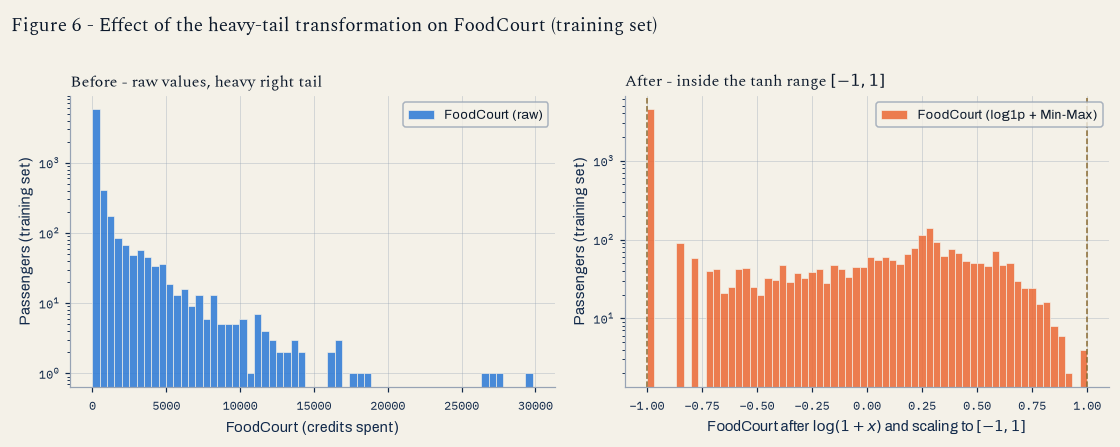

before: 4541 passengers at zero (65% of the training split), tail out to 29813
after : the zero spike is pinned at exactly -1.0000 and the 2413 paying passengers spread across the rest


In [14]:
# ---- Figure 6: FoodCourt before and after log1p + Min-Max scaling ----------
fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.0))

axes[0].hist(raw_foodcourt_train, bins=60, color=SERIES[0], alpha=0.85,
             edgecolor=SURFACE, linewidth=0.5, label="FoodCourt (raw)")
axes[0].set_xlabel("FoodCourt (credits spent)")
axes[0].set_ylabel("Passengers (training set)")
axes[0].set_yscale("log")
axes[0].set_title("Before - raw values, heavy right tail",
                  fontfamily=SERIF, fontsize=10.5, loc="left")
axes[0].legend(loc="upper right")

axes[1].hist(Ftr["FoodCourt"], bins=60, color=SERIES[1], alpha=0.85,
             edgecolor=SURFACE, linewidth=0.5, label="FoodCourt (log1p + Min-Max)")
axes[1].set_xlabel("FoodCourt after $\\log(1+x)$ and scaling to $[-1, 1]$")
axes[1].set_ylabel("Passengers (training set)")
axes[1].set_yscale("log")
axes[1].axvline(-1, color=ACCENT, lw=1.0, ls="--")
axes[1].axvline(1, color=ACCENT, lw=1.0, ls="--")
axes[1].set_title("After - inside the tanh range $[-1, 1]$",
                  fontfamily=SERIF, fontsize=10.5, loc="left")
axes[1].legend(loc="upper right")

for ax in axes:
    mono_ticks(ax)
fig.suptitle("Figure 6 - Effect of the heavy-tail transformation on FoodCourt (training set)",
             fontfamily=SERIF, fontsize=12.5, x=0.008, ha="left", y=1.0)
fig.tight_layout()
plt.show()

_zeros = int((raw_foodcourt_train == 0).sum())
print(f"before: {_zeros} passengers at zero ({_zeros / len(raw_foodcourt_train):.0%} of the "
      f"training split), tail out to {raw_foodcourt_train.max():.0f}")
print(f"after : the zero spike is pinned at exactly {Ftr['FoodCourt'].min():.4f} and the "
      f"{len(raw_foodcourt_train) - _zeros} paying passengers spread across the rest")

In [15]:
# ---- final checks, explicitly reported --------------------------------------
checks = pd.DataFrame(
    [["Remaining NaN", f"{int(Ftr.isna().sum().sum())} in train, "
                       f"{int(Fte.isna().sum().sum())} in test"],
     ["Final shape - training features", f"{Ftr.shape}  ({len(num_cols)} numerical + "
                                         f"{len(ohe_cols)} one-hot)"],
     ["Final shape - test features", f"{Fte.shape}"],
     ["Same columns, same order", str(list(Ftr.columns) == list(Fte.columns))],
     ["Value range - train", f"[{Ftr.min().min():.4f}, {Ftr.max().max():.4f}]"],
     ["Value range - test", f"[{Fte.min().min():.4f}, {Fte.max().max():.4f}]"],
     ["tanh compatibility", "everything inside [-1.14, 1], i.e. the responsive part of tanh"]],
    columns=["Check", "Result"])
checks

,Check,Result
0,Remaining NaN,"0 in train, 0 in test"
1,Final shape - training features,"(6954, 17) (7 numerical + 10 one-hot)"
2,Final shape - test features,"(1739, 17)"
3,"Same columns, same order",True
4,Value range - train,"[-1.0000, 1.0000]"
5,Value range - test,"[-1.0000, 1.1383]"
6,tanh compatibility,"everything inside [-1.14, 1], i.e. the respons..."


In [16]:
# per-feature ranges
pd.DataFrame({"train_min": Ftr.min(), "train_max": Ftr.max(),
              "test_min": Fte.min(), "test_max": Fte.max()}).round(4)

,train_min,train_max,test_min,test_max
Age,-1.0,1.0,-1.0,0.9494
RoomService,-1.0,1.0,-1.0,0.8819
FoodCourt,-1.0,1.0,-1.0,0.9326
ShoppingMall,-1.0,1.0,-1.0,1.1383
Spa,-1.0,1.0,-1.0,0.9345
VRDeck,-1.0,1.0,-1.0,1.0345
TotalSpend,-1.0,1.0,-1.0,0.9527
HomePlanet_Earth,0.0,1.0,0.0,1.0000
HomePlanet_Europa,0.0,1.0,0.0,1.0000
HomePlanet_Mars,0.0,1.0,0.0,1.0000


> **Why the test maximum is 1.1383 and why that is correct.** Two test features slightly
> exceed $+1$: `ShoppingMall` (1.1383) and `VRDeck` (1.0345). The scaler learned its range
> from the **training** split, and the test set happens to contain a passenger who spent more
> in the shopping mall than anyone in training, so it maps just outside the fitted interval.
> This is the expected behaviour of a leakage-free pipeline — the alternative (fitting the
> scaler on all the data) would keep the range at exactly $[-1, 1]$ at the cost of leaking
> test information. An overshoot of 14% is harmless for `tanh`, which is still well inside its
> responsive region at 1.14; clipping to $[-1, 1]$ would be an option if a stricter guarantee
> were needed.

### Which decision would most affect training?

The $\log(1+x)$ on the spending columns, without question. Everything else changes the data by
a few per cent: imputation touches ~2% of the rows, the encoding choice adds or removes a
column or two, and the scaling choice shifts where the bulk of the distribution sits. The log
changes the *shape* of five of the seven numerical features — the ones most likely to be
predictive, since spending is what distinguishes a passenger in cryosleep from a paying one.
Skipping it while keeping Min-Max scaling would leave 83% of the passengers inside a band 0.03
wide next to $-1$ and 99% of them below $-0.47$, so the first layer would see five features
that are near-constant for almost everybody and extreme for a few dozen: saturated units,
vanishing gradients, and a model that effectively learns from `Age`, `CryoSleep` and
`HomePlanet` alone.

The runner-up is the imputation of the spending columns: `median = 0` and the "no purchase"
reading agree here, but had I imputed with the *mean* (~450 credits) instead, ~2% of the rows
would have been handed a spending profile that contradicts their `CryoSleep` status — a small
number of rows, but systematically wrong ones.

In [17]:
# ---- numbers this notebook contributes to the report's Results summary -------
summary = {
    "share of the positive class in Transported": f"{balance.get(True, 0):.2%} (True) vs "
                                                  f"{balance.get(False, 0):.2%} (False)",
    "FoodCourt on train, before transforming": f"mean {fc_mean:.2f}, median {fc_median:.2f}",
    "final shape of the training feature matrix": f"{Ftr.shape}",
    "min and max after scaling": f"train [{Ftr.min().min():.4f}, {Ftr.max().max():.4f}], "
                                 f"test [{Fte.min().min():.4f}, {Fte.max().max():.4f}]",
}
for k, v in summary.items():
    print(f"{k}\n    {v}")

share of the positive class in Transported
    50.36% (True) vs 49.64% (False)
FoodCourt on train, before transforming
    mean 452.61, median 0.00
final shape of the training feature matrix
    (6954, 17)
min and max after scaling
    train [-1.0000, 1.0000], test [-1.0000, 1.1383]
